- Explore data
- Visualize patterns
- Find problems (missing values, outliers)

In [3]:
# import libraries
import pandas as pd

In [4]:
#import the dataset from csv file
df = pd.read_csv("../data/raw/credit_risk_dataset.csv")

In [5]:
# show number of rows and colums
print(df.shape)
# show all colums
print(df.columns)
# show features info
print(df.info())
# preview 
df.head()

(32581, 12)
Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
# descibe the numerical dataset
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
# find duplicate value
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 165


In [8]:
# drop duplicate rows
df = df.drop_duplicates()

# duplicate row after remove
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
numerical_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    lower_outliers = df[df[col] < lower]
    upper_outliers = df[df[col] > upper]

    total_outliers = len(lower_outliers) + len(upper_outliers)

    print(f"{col}: {total_outliers} total outliers "
          f"({total_outliers/len(df)*100:.2f}%)")
    print(f"  Lower bound = {lower}, lower bound outliers = {len(lower_outliers)}")
    print(f"  Upper bound = {upper}, upper bound outliers = {len(upper_outliers)}\n")

person_age: 1491 total outliers (4.60%)
  Lower bound = 12.5, lower bound outliers = 0
  Upper bound = 40.5, upper bound outliers = 1491

person_income: 1478 total outliers (4.56%)
  Lower bound = -22472.0, lower bound outliers = 0
  Upper bound = 140232.0, upper bound outliers = 1478

person_emp_length: 852 total outliers (2.63%)
  Lower bound = -5.5, lower bound outliers = 0
  Upper bound = 14.5, upper bound outliers = 852

loan_amnt: 1679 total outliers (5.18%)
  Lower bound = -5875.0, lower bound outliers = 0
  Upper bound = 23125.0, upper bound outliers = 1679

loan_int_rate: 6 total outliers (0.02%)
  Lower bound = -0.45500000000000007, lower bound outliers = 0
  Upper bound = 21.825000000000003, upper bound outliers = 6

loan_percent_income: 650 total outliers (2.01%)
  Lower bound = -0.12000000000000002, lower bound outliers = 0
  Upper bound = 0.44000000000000006, upper bound outliers = 650

cb_person_cred_hist_length: 1139 total outliers (3.51%)
  Lower bound = -4.5, lower bo

In [10]:
# handle person age by remove impossible age
df = df[df['person_age'] <= 100]

In [11]:
# Cap employment length >50
df.loc[df['person_emp_length'] > 50, 'person_emp_length'] = 50

In [12]:
# check the missing values
print(df.isnull().sum())
print(df.isnull().mean() * 100)

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3094
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64
person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.736725
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.546142
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64


In [13]:
# Fill the employee lenght with median
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Fill interest rate by loan grade median
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'].transform(
    lambda x: x.fillna(x.median())
)

In [14]:
#verify after clean
print(df.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

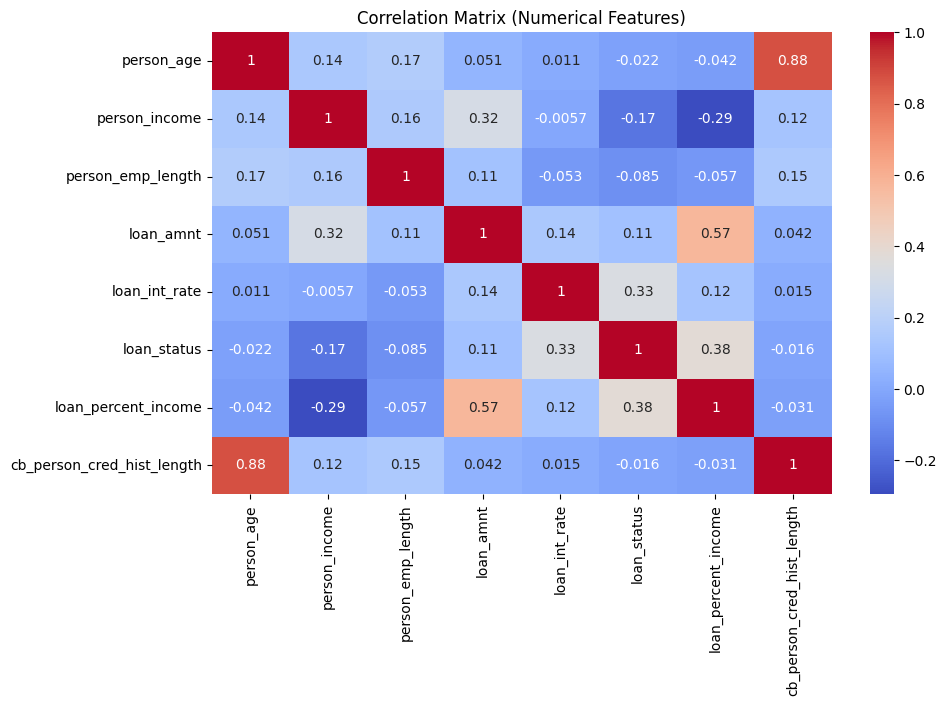

In [16]:
# Select numerical features
num_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = num_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

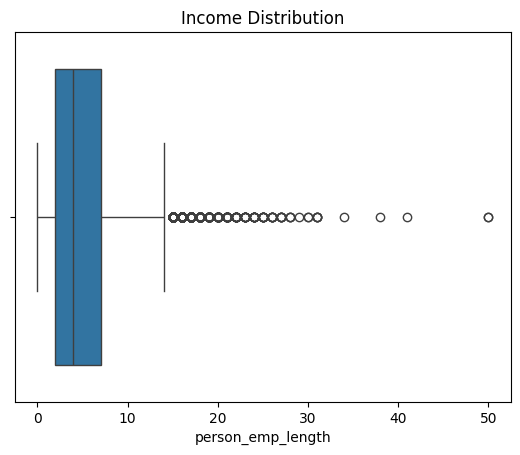

In [17]:

sns.boxplot(x=df['person_emp_length'])
plt.title("Income Distribution")
plt.show()

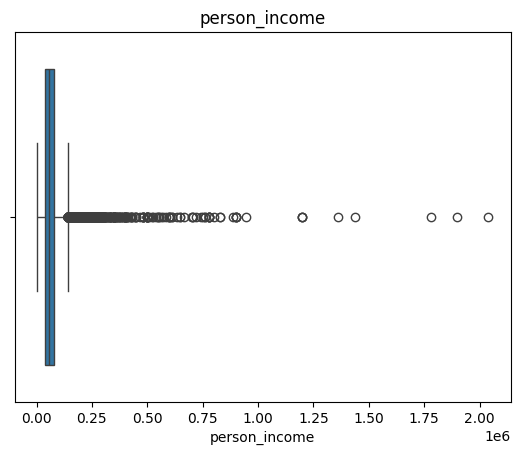

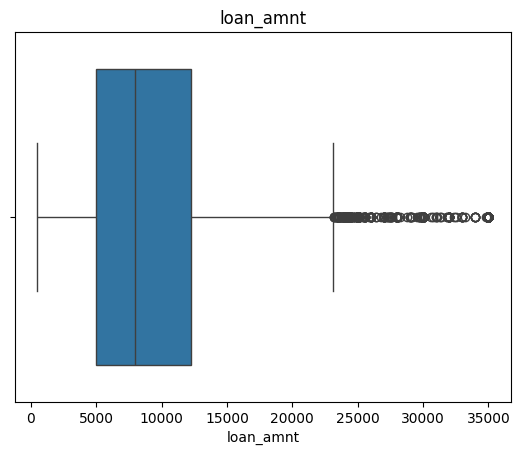

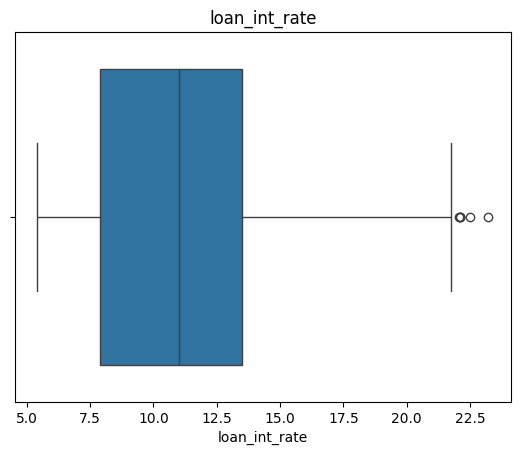

In [18]:
features = ['person_income', 'loan_amnt', 'loan_int_rate']

for col in features:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [19]:
df.shape

(32411, 12)